In [196]:
# conda activate chronocell

import os, sys
import numpy as np
import pandas as pd

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/code")

import Chronocell

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

In [197]:
# Get traj object from running Chronocell
import pickle
with open("eLNPs_var>1.2_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [198]:
def _get_state_per_time(tau, time_grid):
    time_states = np.zeros(shape=time_grid.shape, dtype=int) 
    for k in range(1, len(tau)):  
        idx = (time_grid <= tau[k]) & (time_grid > tau[k-1])
        time_states[idx] = k-1
    return time_states

In [199]:
# Reworked function

In [ ]:
tau = traj.tau # State transition times (global)
time_grid = traj.t # Process time

thetas = traj.theta # Gene-specific parameters
alphas = thetas[:, 1:len(traj.topo.flatten())] # Transcription rates
betas = thetas[:,-2] # Splicing rates
gammas = thetas[:,-1] # Degradation rates

state_per_t = _get_state_per_time(tau, time_grid)
state_counts = np.bincount(state_per_t)
alphas_per_t = np.repeat(alphas, state_counts, axis=1)

posterior_prob = traj.Q.sum(1) # Posterior probabilities of cell being in a given state
starting_state_inds = np.argmax(posterior_prob, axis=1) # Most likely state for each cell

lambda_U = np.empty((traj.X.shape[0], traj.X.shape[1], len(time_grid))) # Shape: cells x genes x time
lambda_S = np.empty((traj.X.shape[0], traj.X.shape[1], len(time_grid)))

# Transcriptional history starts with observed data:
rows = np.arange(lambda_S.shape[0])

lambda_U[rows, :, starting_state_inds] = traj.X[:, :, 0]
lambda_S[rows, :, starting_state_inds] = traj.X[:, :, 1]

m = len(time_grid) 
dt = np.diff(time_grid)

In [234]:

# Which cells are starting at time point k = 99?
np.where(starting_state_inds == 99)

(array([  458,   625,  1262, ..., 21306, 21319, 21321]),)

In [235]:
cell_idx = 458
# Start by looking at a gene with high counts
gene_idx = 6

In [236]:
betas = betas[gene_idx]
gammas = gammas[gene_idx]

In [237]:
for k in reversed(range(1, m)):
    # print(k)
    # mask = starting_state_inds >= k # Any cell at time_k (or later) needs time_k-1 imputed
    # if not np.any(mask):
    #     continue
    
    dt_k = dt[k-1]
    alphas_k1 = alphas_per_t[gene_idx, k-1] # Previous time points' transcription rates

    # Solve for previous time point:
    exp_b = np.exp(-betas * dt_k)
    exp_g = np.exp(-gammas * dt_k)

    lambda_u_k = lambda_U[cell_idx, gene_idx, k]  
    lambda_s_k = lambda_S[cell_idx, gene_idx, k]
    lambda_u_k1 = (lambda_u_k - (alphas_k1 / betas) * (1 - exp_b)) / exp_b
    lambda_u_k1 = np.maximum(lambda_u_k1, 0) # No. RNAs can't be negative
    
    lambda_s_k1 = (lambda_s_k  - (betas / (betas - gammas)) * lambda_u_k1  + (betas * alphas_k1) / (gammas * (betas - gammas)) * (1 - exp_g)) / exp_g
    lambda_s_k1 = np.maximum(lambda_s_k1, 0) 
    
    lambda_U[cell_idx, gene_idx, k-1] = lambda_u_k1
    lambda_S[cell_idx, gene_idx, k-1] = lambda_s_k1

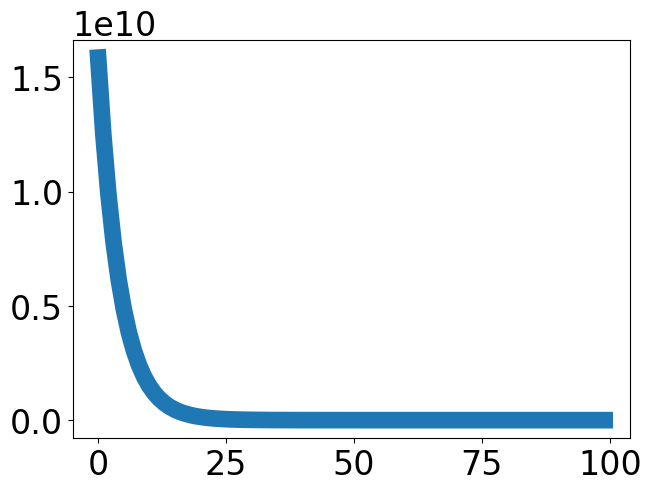

In [238]:
import matplotlib.pyplot as plt
plt.plot(np.arange(m), lambda_S[cell_idx, gene_idx, :])

In [ ]:
# If we plug in the starting point for this gene and cell, we should get back to very low expression, if the recursive equation is accurate.

In [282]:
# topo = np.array([np.array(list(range(0, 4)))], dtype=int)
tau = np.linspace(0, 8, 4)
thetas = traj.theta[458, None]
t = traj.t

In [280]:
start_U = lambda_U[cell_idx, gene_idx, 0]
start_S = lambda_S[cell_idx, gene_idx, 0]

In [284]:
Y = simulate_RNA_from_reconstructed_data(theta, tau, t, start_U, start_S)

In [289]:
np.max(Y)

np.float64(15865738249.818058)

In [290]:
Y.shape

(100, 1, 2)

In [292]:
np.min(Y[:, 0, 1])

np.float64(15865738249.738913)

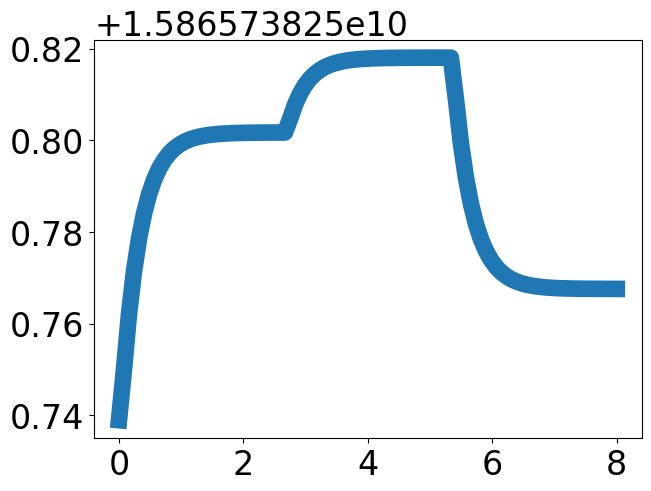

In [291]:
import matplotlib.pyplot as plt
plt.plot(t, Y[:, 0, 1])

In [269]:
Y[:, :, 1]

array([[1.7277216 ],
       [1.75526275],
       [1.94167847],
       [2.02080325],
       [2.0258098 ],
       [2.15901561],
       [2.35858621],
       [2.49159025],
       [2.50475661],
       [2.66314394],
       [2.68086967],
       [2.744425  ],
       [2.75288481],
       [2.76654674],
       [2.76975029],
       [2.77782116],
       [2.81052446],
       [2.81460932],
       [2.81700683],
       [2.82142828],
       [2.82363461],
       [2.82393568],
       [2.82469777],
       [2.82477579],
       [2.82522885],
       [2.82686371],
       [2.82761547],
       [2.82883172],
       [2.82950841],
       [2.82986366],
       [2.82995148],
       [2.8302732 ],
       [2.83067454],
       [2.83069101],
       [2.83076456],
       [2.83097969],
       [2.90770612],
       [3.10677503],
       [3.26549306],
       [3.40791749],
       [3.47426987],
       [3.48174114],
       [3.48482569],
       [3.48907421],
       [3.50671599],
       [3.50866817],
       [3.52879618],
       [3.533

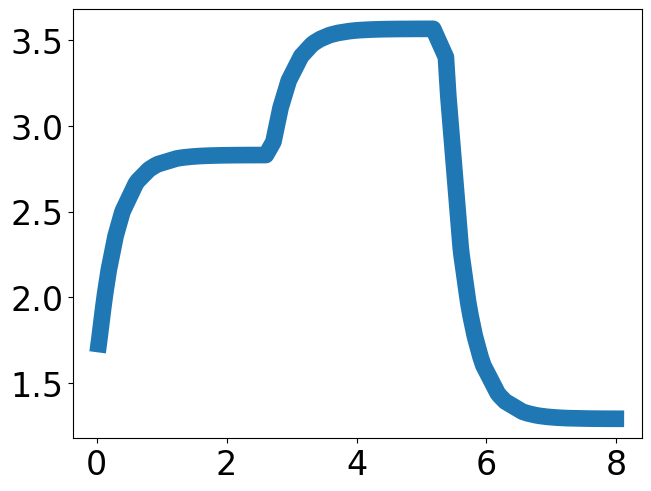

In [265]:
plt.plot(true_t, Y[:, 0, 1])

Check what the RNA trajectory looks like with the same parameters

In [ ]:
for k in reversed(range(1, m)):
    # print(k)
    # mask = starting_state_inds >= k # Any cell at time_k (or later) needs time_k-1 imputed
    # if not np.any(mask):
    #     continue
    
    dt_k = dt[k-1]
    alphas_k1 = alphas_per_t[gene_idx, k-1] # Previous time points' transcription rates

    # Solve for previous time point:
    exp_b = np.exp(-betas * dt_k)
    exp_g = np.exp(-gammas * dt_k)

    lambda_u_k = lambda_U[cell_idx, gene_idx, k]  
    lambda_s_k = lambda_S[cell_idx, gene_idx, k]
    lambda_u_k1 = (lambda_u_k - (alphas_k1 / betas) * (1 - exp_b)) / exp_b
    lambda_u_k1 = np.maximum(lambda_u_k1, 0) # No. RNAs can't be negative
    
    print(lambda_u_k1)
    
    lambda_s_k1 = (lambda_s_k  - (betas / (betas - gammas)) * lambda_u_k1  + (betas * alphas_k1) / (gammas * (betas - gammas)) * (1 - exp_g)) / exp_g
    lambda_s_k1 = np.maximum(lambda_s_k1, 0) 
    print(lambda_s_k1)
    
    lambda_U[cell_idx, gene_idx, k-1] = lambda_u_k1
    lambda_S[cell_idx, gene_idx, k-1] = lambda_s_k1

In [106]:
for k in reversed(range(1, m)):
    print(k)
    mask = starting_state_inds >= k # Any cell at time_k (or later) needs time_k-1 imputed
    if not np.any(mask):
        continue
    
    dt_k = dt[k-1]
    alphas_k1 = alphas_per_t[:, k-1] # Previous time points' transcription rates

    # Solve for previous time point:
    exp_b = np.exp(-betas * dt_k)
    exp_g = np.exp(-gammas * dt_k)

    lambda_u_k = lambda_U[mask, :, k]  
    lambda_s_k = lambda_S[mask, :, k]
    lambda_u_k1 = (lambda_u_k - (alphas_k1 / betas) * (1 - exp_b)) / exp_b
    lambda_u_k1 = np.maximum(lambda_u_k1, 0) # No. RNAs can't be negative

    lambda_s_k1 = (
        lambda_s_k 
            - (betas / (betas - gammas)) * lambda_u_k1 
            + (betas * alphas_k1) / (gammas * (betas - gammas)) * (1 - exp_g)
        ) / exp_g
    lambda_s_k1 = np.maximum(lambda_s_k1, 0) 

    lambda_U[mask, :, k-1] = lambda_u_k1
    lambda_S[mask, :, k-1] = lambda_s_k1

99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69


/tmp/ipykernel_352416/2255342487.py:19: RuntimeWarning: overflow encountered in divide
  lambda_s_k1 = (


68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49


/tmp/ipykernel_352416/2255342487.py:16: RuntimeWarning: overflow encountered in divide
  lambda_u_k1 = (lambda_u_k - (alphas_k1 / betas) * (1 - exp_b)) / exp_b


48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1


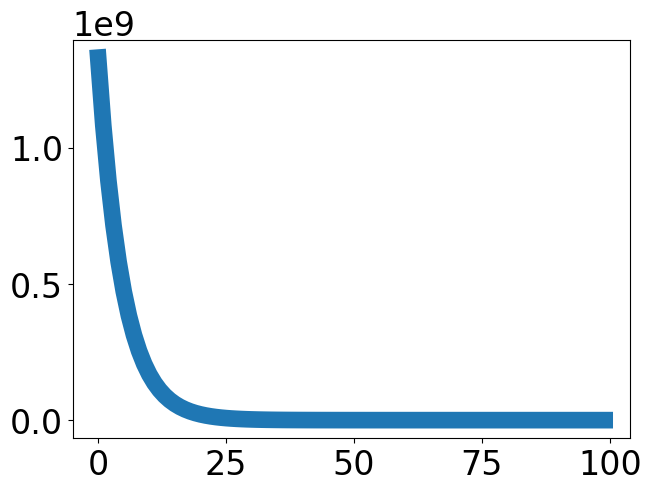

In [126]:
import matplotlib.pyplot as plt
plt.plot(np.arange(m), lambda_S[cell_idx, gene_idx, :])